# Case studies

Six films. I want to see whether the arcs and reversal detection more or less match what actually happens in the scripts. I chose these films because they are structurally distinct from each other: different genres, different tones, and different trajectories. If the pipeline is picking up something real, the shapes should be recognisable without needing to label them.

## 1. Setup

In [10]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

LOCAL_ROOT     = Path('/Users/derinsavasan/Desktop/parsons-spring/thesis')
ARCS_DIR       = LOCAL_ROOT / 'thesis-outputs/arcs'
REVERSALS_PATH = LOCAL_ROOT / 'thesis-outputs/reversals.json'

all_reversals = {r['slug']: r for r in json.loads(REVERSALS_PATH.read_text())}

FILMS = [
    {'slug': 'american-beauty-1999',     'label': 'American Beauty (1999)'},
    {'slug': 'whiplash-2014',            'label': 'Whiplash (2014)'},
    {'slug': 'interstellar-2014',        'label': 'Interstellar (2014)'},
    {'slug': 'there-will-be-blood-2007', 'label': 'There Will Be Blood (2007)'},
    {'slug': 'boogie-nights-1997',       'label': 'Boogie Nights (1997)'},
    {'slug': 'goodfellas-1990',          'label': 'Goodfellas (1990)'},
]

for film in FILMS:
    arc = json.loads((ARCS_DIR / f"{film['slug']}_arc.json").read_text())
    film['arc'] = arc
    film['reversal_data'] = all_reversals[film['slug']]
    ys = [w['z_score'] for w in arc['main_arc']]
    print(f"{film['label']:35s}  tokens={arc['token_count']:,}  reversals={film['reversal_data']['n_reversals']}")

American Beauty (1999)               tokens=26,639  reversals=6
Whiplash (2014)                      tokens=34,745  reversals=12
Interstellar (2014)                  tokens=33,919  reversals=10
There Will Be Blood (2007)           tokens=29,891  reversals=6
Boogie Nights (1997)                 tokens=43,385  reversals=15
Goodfellas (1990)                    tokens=33,651  reversals=13


## 2. Plot helper

In [23]:
plt.rcParams['font.family'] = 'Baskerville'

def plot_film(film, ax_main, ax_reversal):
    arc  = film['arc']
    rdat = film['reversal_data']

    # Main arc
    main_x = [w['position'] for w in arc['main_arc']]
    main_y = [w['z_score']  for w in arc['main_arc']]

    ax_main.plot(main_x, main_y, color='black', linewidth=2, marker='o', markersize=4, zorder=3)
    ax_main.fill_between(main_x, main_y, 0, where=[y >= 0 for y in main_y],
                         alpha=0.15, color='#999999', zorder=2)
    ax_main.fill_between(main_x, main_y, 0, where=[y < 0 for y in main_y],
                         alpha=0.25, color='#444444', zorder=2)
    ax_main.axhline(0, color='gray', lw=1, alpha=0.5)
    ax_main.set_xlim(0, 1)
    ax_main.set_title(f"{film['label']} main arc", fontsize=13, fontweight='bold')
    ax_main.set_xlabel('Story progress', fontsize=11)
    ax_main.set_ylabel('Z-score', fontsize=11)
    ax_main.tick_params(labelsize=10)
    ax_main.grid(True, alpha=0.3)

    # Secondary arc + reversals
    sec_x = [w['position']       for w in arc['secondary_arc']]
    sec_y = [w['smoothed_score'] for w in arc['secondary_arc']]

    ax_reversal.plot(sec_x, sec_y, color='black', linewidth=1.2, zorder=2)
    ax_reversal.axhline(0, color='gray', lw=1, alpha=0.5)

    reversals = rdat.get('reversals', [])
    peaks   = [r for r in reversals if r['type'] == 'peak']
    troughs = [r for r in reversals if r['type'] == 'trough']

    if peaks:
        ax_reversal.scatter([r['position'] for r in peaks], [r['value'] for r in peaks],
                            color='black', zorder=5, s=40, label=f'peaks ({len(peaks)})')
    if troughs:
        ax_reversal.scatter([r['position'] for r in troughs], [r['value'] for r in troughs],
                            facecolors='white', edgecolors='black', linewidths=1.2,
                            zorder=5, s=40, label=f'troughs ({len(troughs)})')

    n_rev = rdat.get('n_reversals', len(reversals))
    ax_reversal.set_xlim(0, 1)
    ax_reversal.set_title(f'{n_rev} reversals detected', fontsize=13, fontweight='bold')
    ax_reversal.set_xlabel('Story progress', fontsize=11)
    ax_reversal.set_ylabel('Smoothed sentiment', fontsize=11)
    ax_reversal.tick_params(labelsize=10)
    ax_reversal.grid(True, alpha=0.3)
    if peaks or troughs:
        ax_reversal.legend(frameon=False, fontsize=10)

## 3. American Beauty (1999)

Lester Burnham opens the film in a kind of numbed misery. He hates his job, his marriage is hollow, he feels invisible. The script reflects this: the first window is the lowest in this set at -2.65. From there the arc climbs as he quits his job, starts exercising, pursues Angela. It never becomes fully positive but the direction is upward, ending at +1.90. Six reversals, which is on the low end, consistent with a fairly linear climb rather than a jagged one.

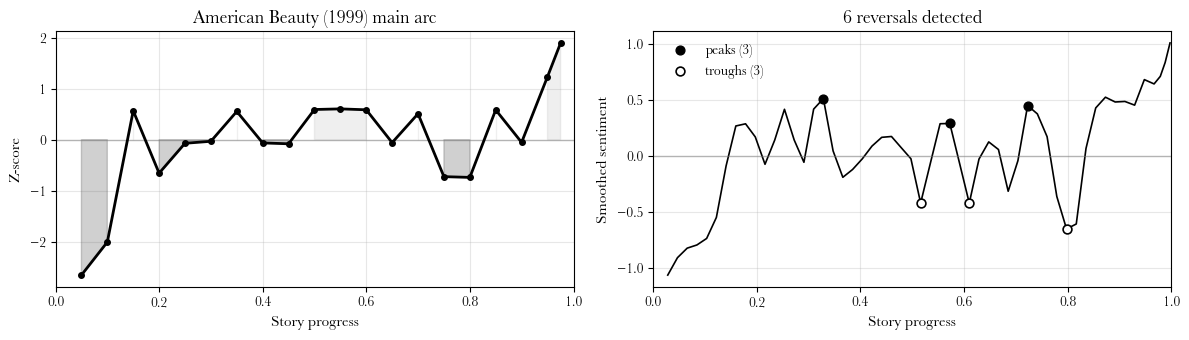

In [24]:
film = FILMS[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_film(film, axes[0], axes[1])
plt.tight_layout()
plt.show()

## 4. Whiplash (2014)

Andrew starts with genuine ability and early promise, then Fletcher systematically destroys him. The first window is +0.77, it drops to -1.21 at the midpoint as the psychological pressure peaks, then ends at +2.26 with the Caravan performance. The arc has the largest swing from its lowest to its highest point of any film here. Twelve reversals, which reflects how many times the film oscillates between Andrew breaking down and pushing through before the final resolution.

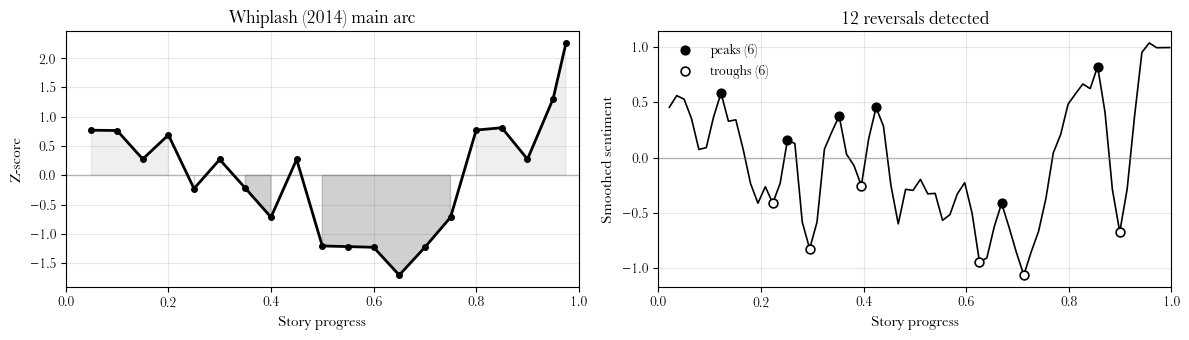

In [25]:
film = FILMS[1]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_film(film, axes[0], axes[1])
plt.tight_layout()
plt.show()

## 5. Interstellar (2014)

Cooper leaves his family behind to try to save the species. The early windows are negative as he separates from Murph, then rise briefly as the mission begins, then crash hard around the midpoint (-1.41 at w10) during the water planet and Mann sequences. The final act pulls back up to +1.97. The shape is not a clean V but a jagged recovery with a lot of turbulence in the second half, which matches the structure of the film: no single moment of crisis but a series of compounding losses before the resolution.

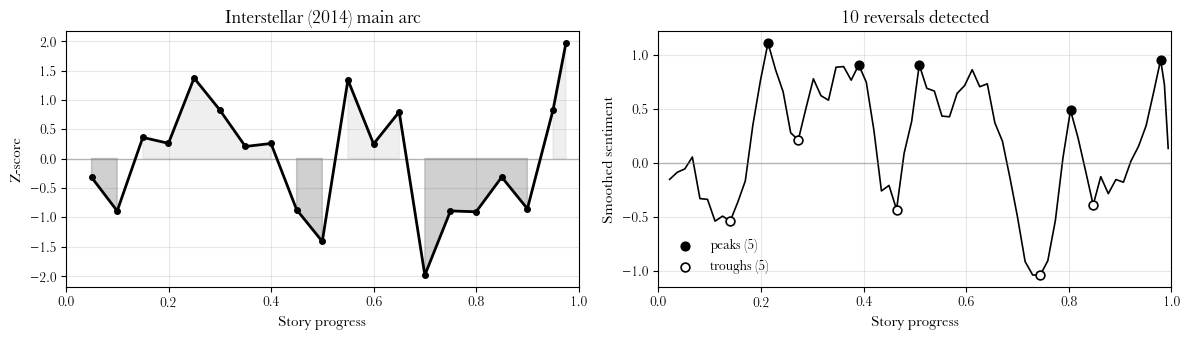

In [26]:
film = FILMS[2]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_film(film, axes[0], axes[1])
plt.tight_layout()
plt.show()

## 6. There Will Be Blood (2007)

Daniel Plainview starts the film as a capable, driven man and ends it as something else entirely. The arc starts at +1.31 and descends almost without interruption to -2.11, the lowest endpoint in this set. Six reversals, same as American Beauty, but the direction is the opposite. The pipeline is reading this correctly: the language of the script gets progressively darker as Plainview's contempt for everyone around him becomes the dominant register.

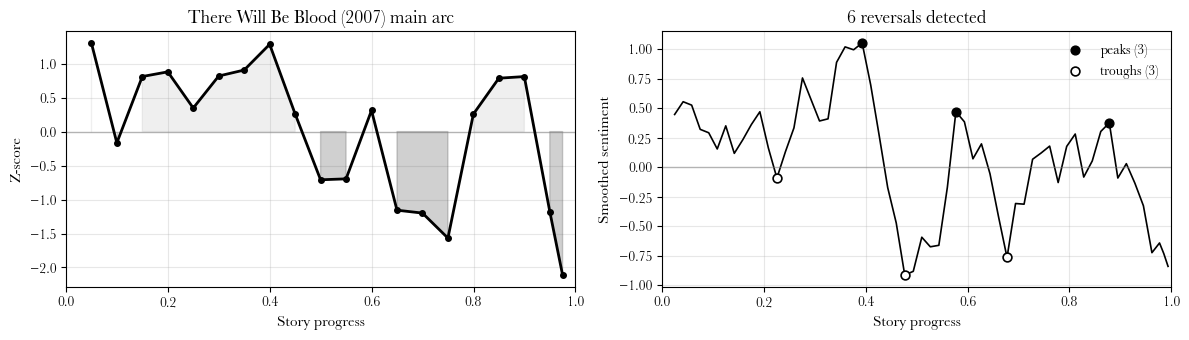

In [27]:
film = FILMS[3]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_film(film, axes[0], axes[1])
plt.tight_layout()
plt.show()

## 7. Boogie Nights (1997)

Dirk Diggler is discovered, rises fast, and then loses everything to drugs and bad decisions. The arc stays positive through the first half (w1=+0.88, w10=+0.88) then falls sharply in the second half as the industry changes and Dirk's personal life collapses (-1.21 at w15, -0.19 at w20). Fifteen reversals, the highest in this set, which reflects how episodic the film is: Anderson builds the collapse out of many small incidents rather than one clean break.

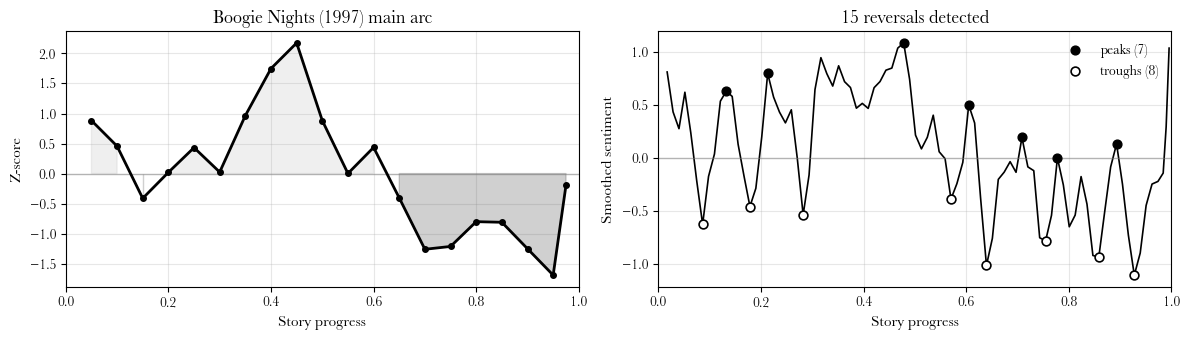

In [28]:
film = FILMS[4]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_film(film, axes[0], axes[1])
plt.tight_layout()
plt.show()

## 8. Goodfellas (1990)

Henry Hill starts as an outsider who wants in, builds his way up through the mob, reaches a kind of peak in the drug years, then gets arrested and loses everything by becoming a rat. The arc starts modestly positive, dips mid-film (-1.00 at w10) as the violence and paranoia escalate, peaks again at w15 (+1.50), then ends negative at -1.05. The pipeline catches the three-phase structure reasonably well: an early rise, a middle crash, a second rise, and a final fall. Thirteen reversals reflects how densely plotted the script is.

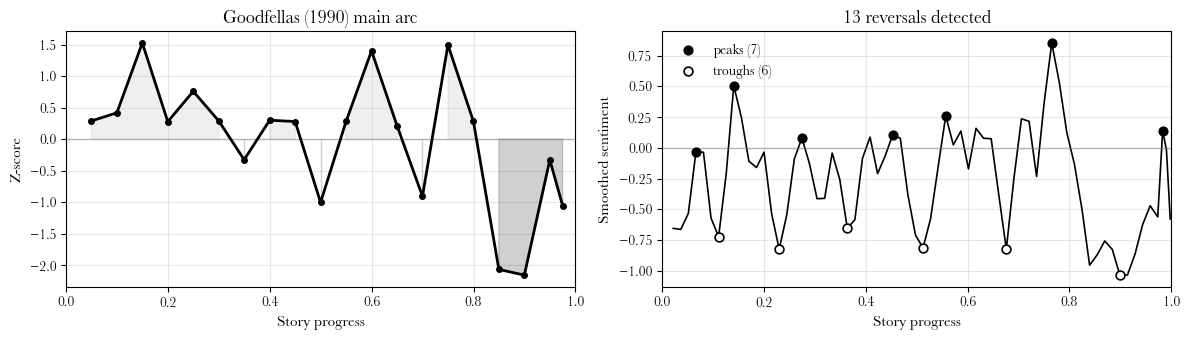

In [29]:
film = FILMS[5]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_film(film, axes[0], axes[1])
plt.tight_layout()
plt.show()

## 9. Notting Hill (1999)

A romantic comedy, included as a contrast to the other six. Starts high at +1.44, dips through the middle as William and Anna fall apart, then ends at the top of its range at +2.01. Fifteen reversals is the highest count in this notebook, which reflects how much the script oscillates between warmth and awkwardness throughout. The shape is broadly positive but with a lot of texture underneath.

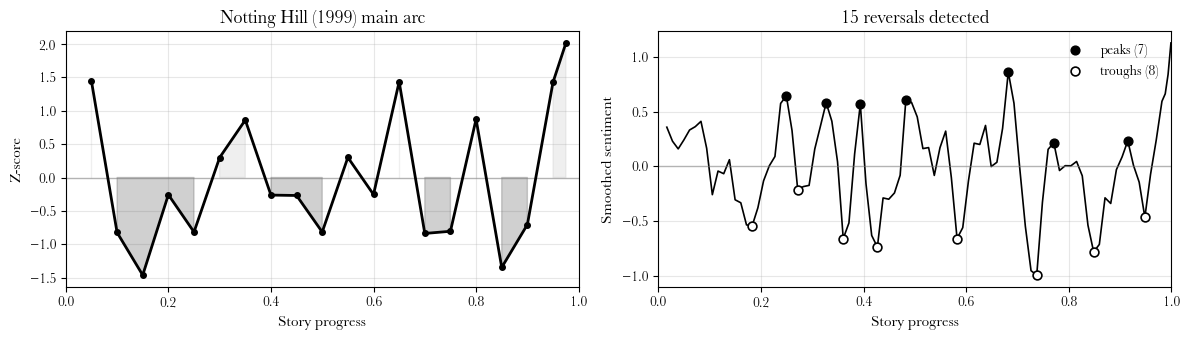

In [30]:
notting_hill = {'slug': 'notting-hill-1999', 'label': 'Notting Hill (1999)'}
arc = json.loads((ARCS_DIR / f"{notting_hill['slug']}_arc.json").read_text())
notting_hill['arc'] = arc
notting_hill['reversal_data'] = all_reversals[notting_hill['slug']]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_film(notting_hill, axes[0], axes[1])
plt.tight_layout()
plt.show()

## 10. Blade Runner 2049 (2017)

This one is not part of the six case studies above. I wanted to include it separately because it is structurally interesting as a contrast. The film is slow, deliberately elliptical, and emotionally suppressed by design. Seven reversals is the lowest count in this set by a wide margin, and the arc barely moves across the whole film. If the pipeline is sensitive to emotional texture, this is what a flat one looks like.

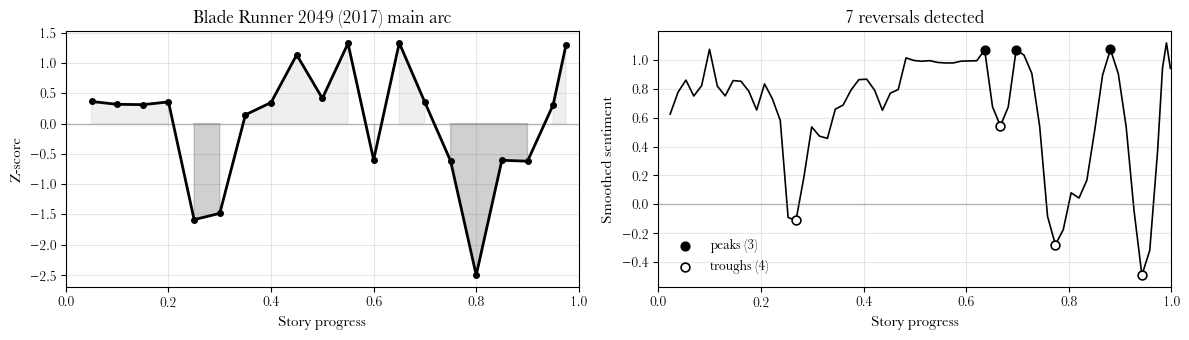

In [31]:
br2049 = {'slug': 'blade-runner-2049-2017', 'label': 'Blade Runner 2049 (2017)'}
arc = json.loads((ARCS_DIR / f"{br2049['slug']}_arc.json").read_text())
br2049['arc'] = arc
br2049['reversal_data'] = all_reversals[br2049['slug']]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_film(br2049, axes[0], axes[1])
plt.tight_layout()
plt.show()

## 11. All six on a shared scale

All six main arcs together on a shared y-axis. The diversity of shapes should be legible here: two that end high and start low, one that starts high and ends at the floor, one that peaks early and falls, one that crashes mid-film and recovers, and one that oscillates across three phases.

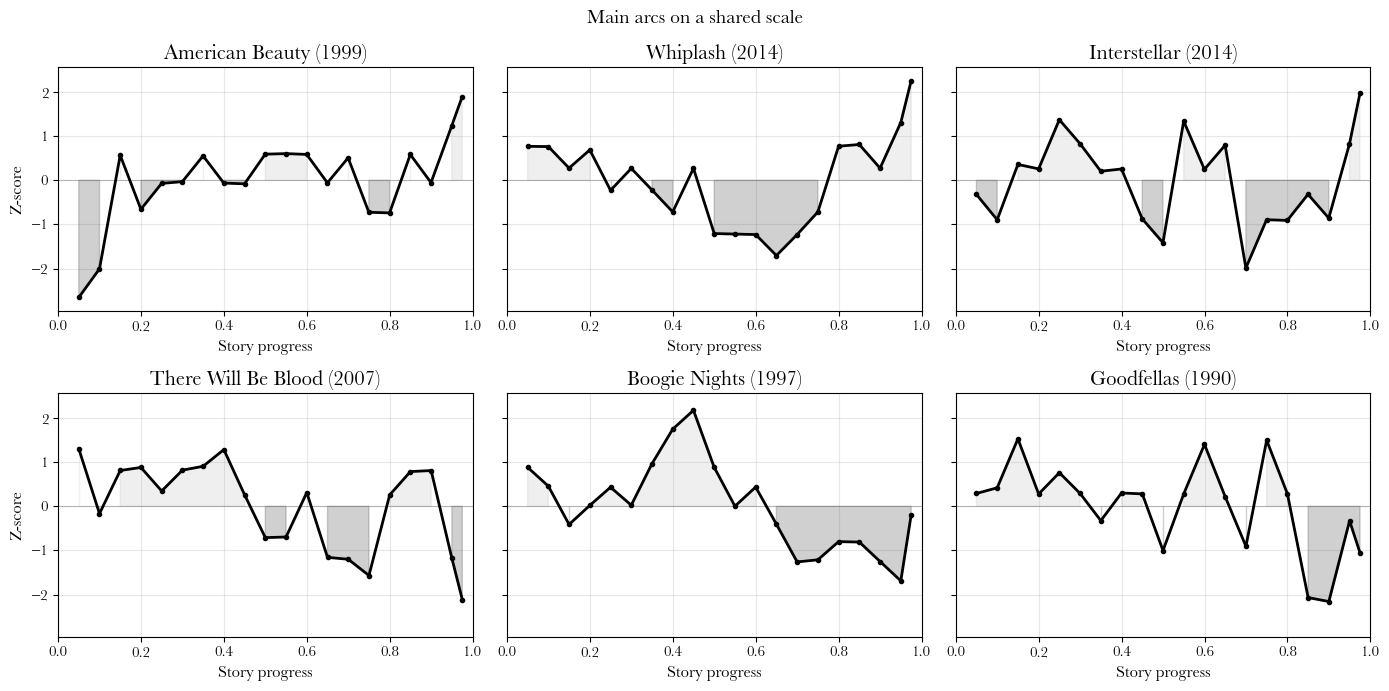

In [32]:
all_z = [w['z_score'] for film in FILMS for w in film['arc']['main_arc']]
y_lim = (min(all_z) - 0.3, max(all_z) + 0.3)

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
axes_flat = axes.flatten()

for ax, film in zip(axes_flat, FILMS):
    xs = [w['position'] for w in film['arc']['main_arc']]
    ys = [w['z_score']  for w in film['arc']['main_arc']]

    ax.plot(xs, ys, color='black', linewidth=2, marker='o', markersize=3, zorder=3)
    ax.fill_between(xs, ys, 0, where=[y >= 0 for y in ys], alpha=0.15, color='#999999', zorder=2)
    ax.fill_between(xs, ys, 0, where=[y < 0 for y in ys],  alpha=0.25, color='#444444', zorder=2)
    ax.axhline(0, color='gray', lw=0.8, alpha=0.5)
    ax.set_ylim(y_lim)
    ax.set_xlim(0, 1)
    ax.set_title(film['label'], fontsize=15, fontweight='heavy')
    ax.set_xlabel('Story progress', fontsize=12)
    ax.tick_params(labelsize=11)
    ax.grid(True, alpha=0.3)

axes[0][0].set_ylabel('Z-score', fontsize=12)
axes[1][0].set_ylabel('Z-score', fontsize=12)

plt.suptitle('Main arcs on a shared scale', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()